In [1]:
import os
import glob
from tqdm import tqdm
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from matplotlib import colors
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.default"] = "rm"
plt.rcParams['text.usetex'] = True
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.ndimage import gaussian_filter
from matplotlib.colors import Normalize

In [2]:
## function to flatten list of lists #######
def flatten(t):
    return np.array([item for sublist in t for item in sublist])

In [3]:
dir_ = '/work/Lund/OT_Lund/create_Lund/images_500/'

Images_pythia = np.load(dir_+'Images_pythia_qcd.npz',allow_pickle=True)['arr_0']
Images_herwig = np.load(dir_+'Images_herwig_qcd.npz',allow_pickle=True)['arr_0']
print(f'Shape of pythia images: {Images_pythia.shape}')
print(f'Shape of herwig images: {Images_herwig.shape}')

Shape of pythia images: (100000, 1, 50, 50)
Shape of herwig images: (100000, 1, 50, 50)


In [4]:
im_p = flatten(Images_pythia)
im_h = flatten(Images_herwig)

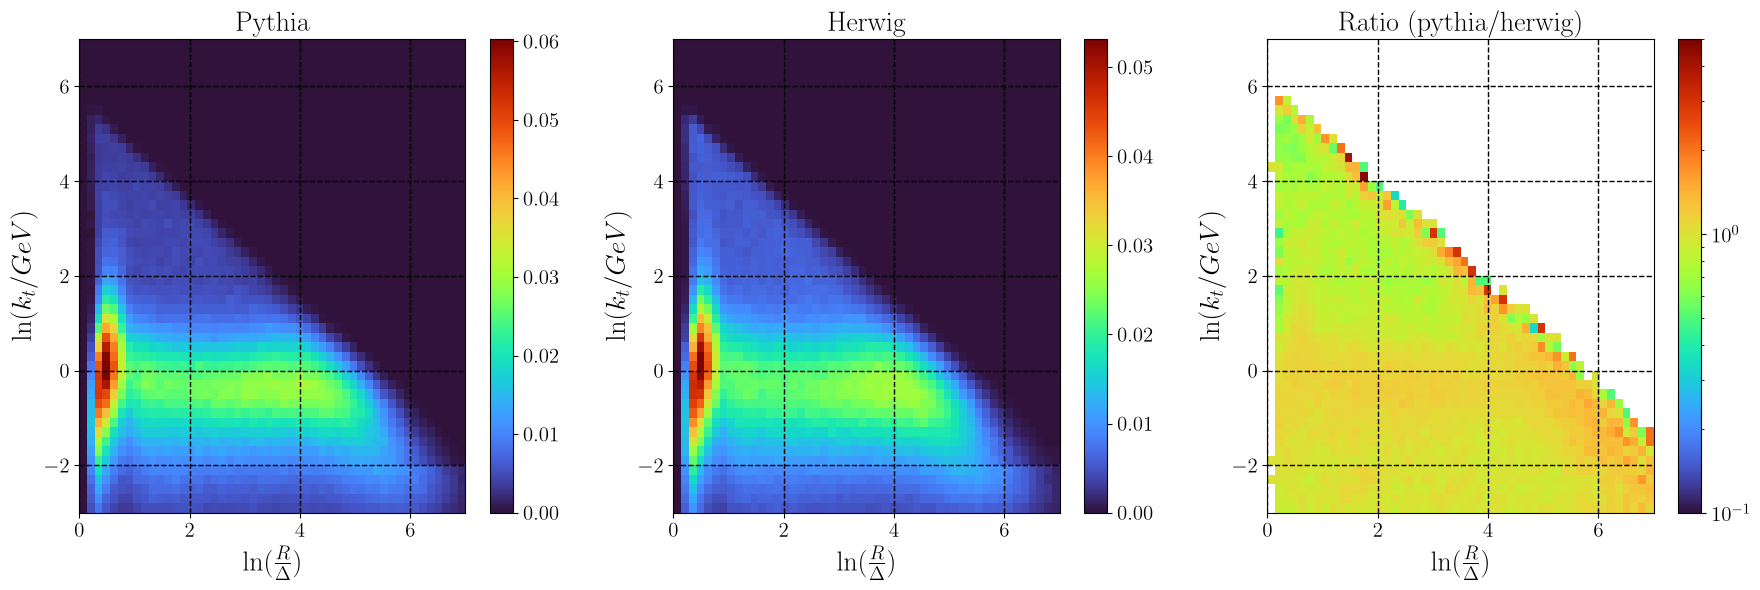

In [5]:
 ## Plot Lund Images for the SM and the DM
xval = [0,7]
yval = [-3,7]
fig = plt.figure(figsize=(18,6))
fig.subplots_adjust(hspace=1, wspace=1)
y1 = fig.add_subplot(131)
c1=y1.imshow(np.average(im_p,axis=0).T,origin='lower',aspect='auto',extent=xval+yval,cmap='turbo')
y1.set_title(r'Pythia',fontsize=20)
y1.set_xlabel(r'$\ln(\frac{R}{\Delta})$',fontsize=20)
y1.set_ylabel(r'$\ln(k_t/GeV)$',fontsize=20)
plt.tick_params(axis='both',labelsize=15)
plt.colorbar(c1).ax.tick_params(labelsize=15)
y1.grid(color='k',linestyle='--',linewidth=1.01)

y2 = fig.add_subplot(132)
c2=y2.imshow(np.average(im_h,axis=0).T,origin='lower',aspect='auto',extent=xval+yval,cmap='turbo')
y2.set_title(r'Herwig',fontsize=20)
y2.set_xlabel(r'$\ln(\frac{R}{\Delta})$',fontsize=20)
y2.set_ylabel(r'$\ln(k_t/GeV)$',fontsize=20)
plt.tick_params(axis='both',labelsize=15)
plt.colorbar(c2).ax.tick_params(labelsize=15)
y2.grid(color='k',linestyle='--',linewidth=1.01)

pythia = abs(np.average(im_p, axis=0)).T
herwig = abs(np.average(im_h, axis=0)).T

ratio =  np.divide(
    pythia,
    herwig,
    out=np.zeros_like(pythia, dtype=float),
    where=herwig != 0
)

y3 = fig.add_subplot(133)
c3=y3.imshow(ratio,origin='lower',aspect='auto',extent=xval+yval,cmap='turbo',norm=LogNorm(vmin=0.1, vmax=5))
y3.set_title(r'Ratio (pythia/herwig)',fontsize=20)
y3.set_xlabel(r'$\ln(\frac{R}{\Delta})$',fontsize=20)
y3.set_ylabel(r'$\ln(k_t/GeV)$',fontsize=20)
plt.tick_params(axis='both',labelsize=15)
plt.colorbar(c3).ax.tick_params(labelsize=15)
y3.grid(color='k',linestyle='--',linewidth=1.01)



plt.tight_layout()

plt.savefig('Lun_SM.pdf')

In [6]:
XVAL, YVAL = [0, 7], [-3, 7]          # ln(R/Delta), ln(kt/GeV)
EXTENT = XVAL + YVAL
MIN_JETS_PER_BIN = 20 
SMOOTH = 1.0 

In [7]:
def stats(im):
    """Per-bin mean and standard error of the mean, plus occupancy."""
    n = im.shape[0]
    mean = im.mean(axis=0)
    sem = im.std(axis=0, ddof=1) / np.sqrt(n)
    filled = (im > 0).sum(axis=0)     # how many jets actually populate the bin
    return mean.T, sem.T, filled.T    # .T -> (ny, nx) for imshow

In [8]:

def comparison_figure(im_p, im_h, fname="lund_comparison.pdf"):
    mp, sp, np_fill = stats(im_p)
    mh, sh, nh_fill = stats(im_h)
 
    # bins with too few contributing jets in EITHER sample are not interpretable
    poor = (np_fill < MIN_JETS_PER_BIN) | (nh_fill < MIN_JETS_PER_BIN)
 
    # --- shared colour scale for the two generators -----------------------
    vmax = np.nanpercentile(np.concatenate([mp.ravel(), mh.ravel()]), 99.5)
 
    # --- log2 ratio: 0 = identical, +-1 = factor 2 ------------------------
    with np.errstate(divide="ignore", invalid="ignore"):
        log2r = np.log2(mp / mh)
    log2r = np.ma.masked_array(log2r, mask=poor | ~np.isfinite(log2r))
 
    # --- significance of the difference ------------------------------------
    denom = np.sqrt(sp**2 + sh**2)
    with np.errstate(divide="ignore", invalid="ignore"):
        pull = (mp - mh) / denom
    pull = np.ma.masked_array(pull, mask=poor | ~np.isfinite(pull))
 
    fig, ax = plt.subplots(2, 2, figsize=(13, 10))
    kw = dict(origin="lower", aspect="auto", extent=EXTENT)
 
    panels = [
        (ax[0, 0], mp,    "Pythia",           dict(cmap="turbo", vmin=0, vmax=vmax)),
        (ax[0, 1], mh,    "Herwig",           dict(cmap="turbo", vmin=0, vmax=vmax)),
        (ax[1, 0], log2r, r"$\log_2$(Pythia / Herwig)",
         dict(cmap="RdBu_r", norm=TwoSlopeNorm(vcenter=0, vmin=-1.5, vmax=1.5))),
        (ax[1, 1], pull,  r"$(\mu_{\rm P}-\mu_{\rm H})/\sigma$",
         dict(cmap="RdBu_r", norm=TwoSlopeNorm(vcenter=0, vmin=-5, vmax=5))),
    ]
 
    for a, data, title, style in panels:
        cmap = plt.get_cmap(style["cmap"]).copy()
        cmap.set_bad("0.85")                       # masked bins: light grey
        style = {**style, "cmap": cmap}
        c = a.imshow(data, **kw, **style)
        a.set_title(title, fontsize=16)
        a.set_xlabel(r"$\ln(R/\Delta)$", fontsize=14)
        a.set_ylabel(r"$\ln(k_t/{\rm GeV})$", fontsize=14)
        a.tick_params(labelsize=12)
        a.grid(color="k", ls="--", lw=0.5, alpha=0.4)
        plt.colorbar(c, ax=a).ax.tick_params(labelsize=12)
 
    fig.tight_layout()
    fig.savefig(fname)
    print(f"wrote {fname}")
 
    # scalar summary -- one number for the abstract
    chi2 = float(np.ma.sum(pull**2))
    ndf = int(np.ma.count(pull))
    print(f"chi2/ndf between the two generators = {chi2/ndf:.2f}  (ndf={ndf})")
    print(f"fraction of usable bins with |pull| > 3: "
          f"{float(np.ma.mean(np.abs(pull) > 3)):.3f}")

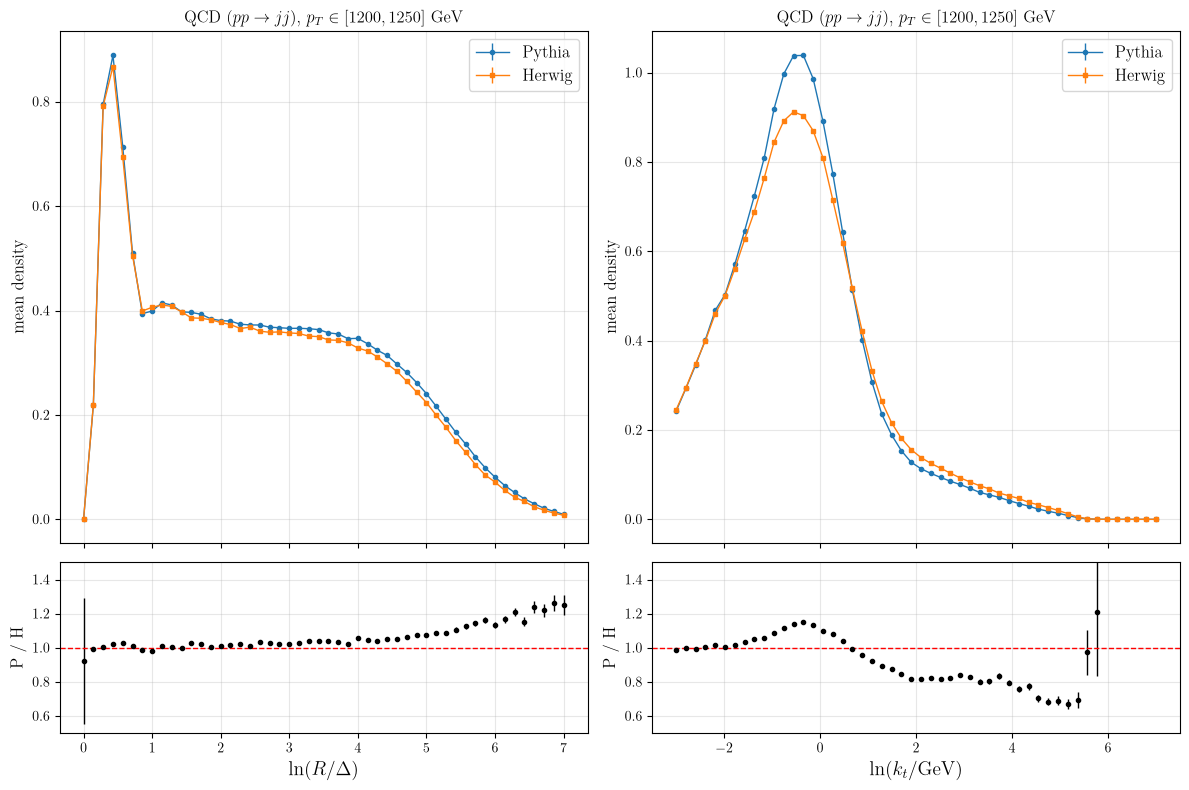

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8),gridspec_kw={"height_ratios": [3, 1]}, sharex="col")
 
for col, (axis, label, rng) in enumerate([(2, r"$\ln(R/\Delta)$", XVAL), (1, r"$\ln(k_t/{\rm GeV})$", YVAL)]):
        # sum over the OTHER axis (axis index 1 or 2 of the (n, nx, ny) array)
    pp = im_p.sum(axis=axis)
    hh = im_h.sum(axis=axis)
    x = np.linspace(rng[0], rng[1], pp.shape[1])
 
    mp, sp = pp.mean(0), pp.std(0, ddof=1) / np.sqrt(len(pp))
    mh, sh = hh.mean(0), hh.std(0, ddof=1) / np.sqrt(len(hh))
 
    top, bot = axes[0, col], axes[1, col]
    top.errorbar(x, mp, yerr=sp, fmt="o-", ms=3, lw=1, label="Pythia")
    top.errorbar(x, mh, yerr=sh, fmt="s-", ms=3, lw=1, label="Herwig")
    top.set_ylabel("mean density", fontsize=12)
    top.set_title(r"QCD $(pp\to jj)$, $p_T \in [1200,1250]$ GeV", fontsize=12)
    top.legend(fontsize=12)
    top.grid(alpha=0.3)
 
    with np.errstate(divide="ignore", invalid="ignore"):
        r = mp / mh
        dr = r * np.sqrt((sp / mp)**2 + (sh / mh)**2)
    bot.errorbar(x, r, yerr=dr, fmt="o", ms=3, lw=1, color="k")
    bot.axhline(1.0, color="r", ls="--", lw=1)
    bot.set_ylim(0.5, 1.5)
    bot.set_ylabel("P / H", fontsize=12)
    bot.set_xlabel(label, fontsize=14)
    bot.grid(alpha=0.3)
 
fig.tight_layout()
plt.savefig('stat_mean_qcd.pdf')

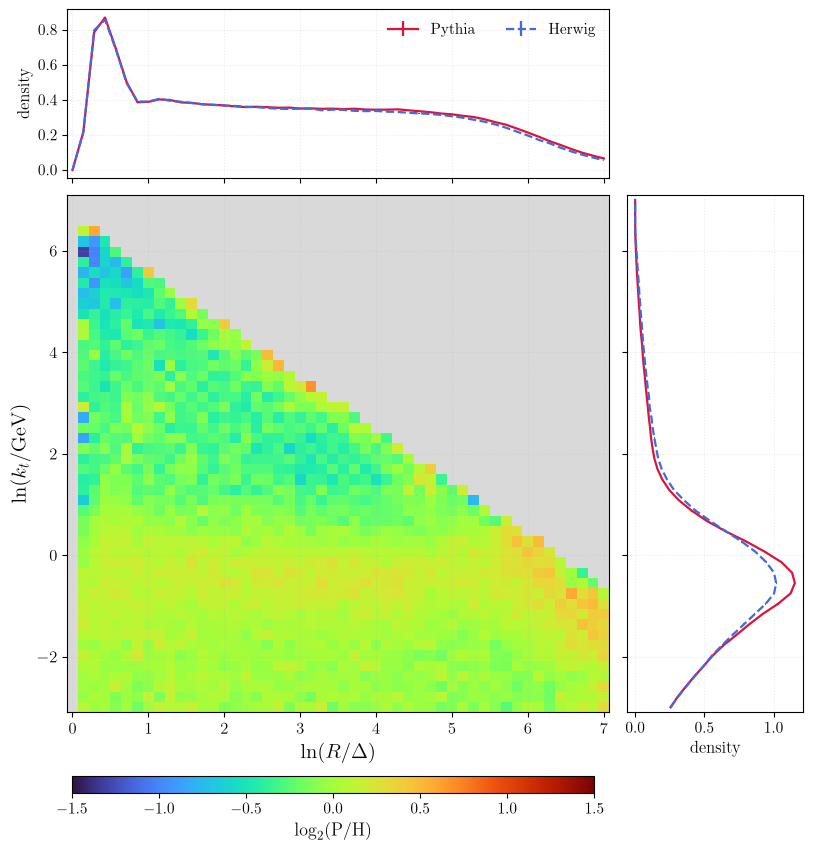

In [88]:
CENTRE = "ratio"
nx, ny = im_p.shape[1], im_p.shape[2]
x = np.linspace(XVAL[0], XVAL[1], nx)
y = np.linspace(YVAL[0], YVAL[1], ny)
X, Y = np.meshgrid(x, y)
 
mp, mh = im_p.mean(0).T, im_h.mean(0).T                 # (ny, nx)
sp = im_p.std(0, ddof=1).T / np.sqrt(len(im_p))
sh = im_h.std(0, ddof=1).T / np.sqrt(len(im_h))
poor = (((im_p > 0).sum(0).T < MIN_JETS_PER_BIN) | (im_h > 0).sum(0).T < MIN_JETS_PER_BIN)
 
# ---- marginals: sum over the other axis, per jet, THEN average --------
# (summing per jet keeps the per-jet spread, which is what the error bars
#  need; averaging first would throw it away)
proj_x_p, proj_x_h = im_p.sum(axis=2), im_h.sum(axis=2)   # vs ln(R/Delta)
proj_y_p, proj_y_h = im_p.sum(axis=1), im_h.sum(axis=1)   # vs ln(kt)
 
def mstats(a):
    return a.mean(0), a.std(0, ddof=1) / np.sqrt(len(a))
 
mx_p, ex_p = mstats(proj_x_p)
mx_h, ex_h = mstats(proj_x_h)
my_p, ey_p = mstats(proj_y_p)
my_h, ey_h = mstats(proj_y_h)
 
# ---- layout -----------------------------------------------------------
fig = plt.figure(figsize=(9.5, 9.5))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1.3), height_ratios=(1.3, 4),
                          wspace=0.05, hspace=0.05)
ax_c = fig.add_subplot(gs[1, 0])
ax_t = fig.add_subplot(gs[0, 0], sharex=ax_c)
ax_r = fig.add_subplot(gs[1, 1], sharey=ax_c)
 
# ---- centre -----------------------------------------------------------
cmap = plt.get_cmap("turbo").copy()
cmap.set_bad("0.85")
 
if CENTRE == "overlay":
    smp = gaussian_filter(mp, SMOOTH) if SMOOTH else mp
    smh = gaussian_filter(mh, SMOOTH) if SMOOTH else mh
    lv = max(smp.max(), smh.max()) * np.array([.05, .15, .3, .5, .7, .9])
    ax_c.contour(X, Y, smp, levels=lv, colors="crimson", linewidths=1.6)
    ax_c.contour(X, Y, smh, levels=lv, colors="royalblue", linewidths=1.6, linestyles="--")
    mappable = None
else:
    if CENTRE == "ratio":
        with np.errstate(divide="ignore", invalid="ignore"):
            Z = np.log2(mp / mh)
        norm, label = TwoSlopeNorm(0, -1.5, 1.5), r"$\log_2$(P/H)"
    else:
        with np.errstate(divide="ignore", invalid="ignore"):
            Z = (mp - mh) / np.sqrt(sp**2 + sh**2)
        norm, label = TwoSlopeNorm(0, -5, 5), r"$(\mu_P-\mu_H)/\sigma$"
    Z = np.ma.masked_array(Z, mask=poor | ~np.isfinite(Z))
    mappable = ax_c.pcolormesh(X, Y, Z, cmap=cmap, norm=norm, shading="auto")
 
ax_c.set_xlabel(r"$\ln(R/\Delta)$", fontsize=15)
ax_c.set_ylabel(r"$\ln(k_t/{\rm GeV})$", fontsize=15)
ax_c.tick_params(labelsize=12)
ax_c.grid(alpha=0.25, ls=":")
 
# ---- top marginal: vs ln(R/Delta) -------------------------------------
ax_t.errorbar(x, mx_p, yerr=ex_p, fmt="-", color="crimson", lw=1.6,label="Pythia")
ax_t.errorbar(x, mx_h, yerr=ex_h, fmt="--", color="royalblue", lw=1.6,label="Herwig")
ax_t.set_ylabel("density", fontsize=12)
ax_t.legend(fontsize=11, ncol=2, frameon=False)
ax_t.tick_params(labelbottom=False, labelsize=11)
ax_t.grid(alpha=0.25, ls=":")
 
# ---- right marginal: vs ln(kt), axes swapped --------------------------
ax_r.errorbar(my_p, y, xerr=ey_p, fmt="-", color="crimson", lw=1.6)
ax_r.errorbar(my_h, y, xerr=ey_h, fmt="--", color="royalblue", lw=1.6)
ax_r.set_xlabel("density", fontsize=12)
ax_r.tick_params(labelleft=False, labelsize=11)
ax_r.grid(alpha=0.25, ls=":")
 
if mappable is not None:
    cax = fig.add_axes([0.13, 0.055, 0.55, 0.018])
    cb = fig.colorbar(mappable, cax=cax, orientation="horizontal")
    cb.set_label(label, fontsize=13)
    cb.ax.tick_params(labelsize=11)
    fig.subplots_adjust(bottom=0.14)
    

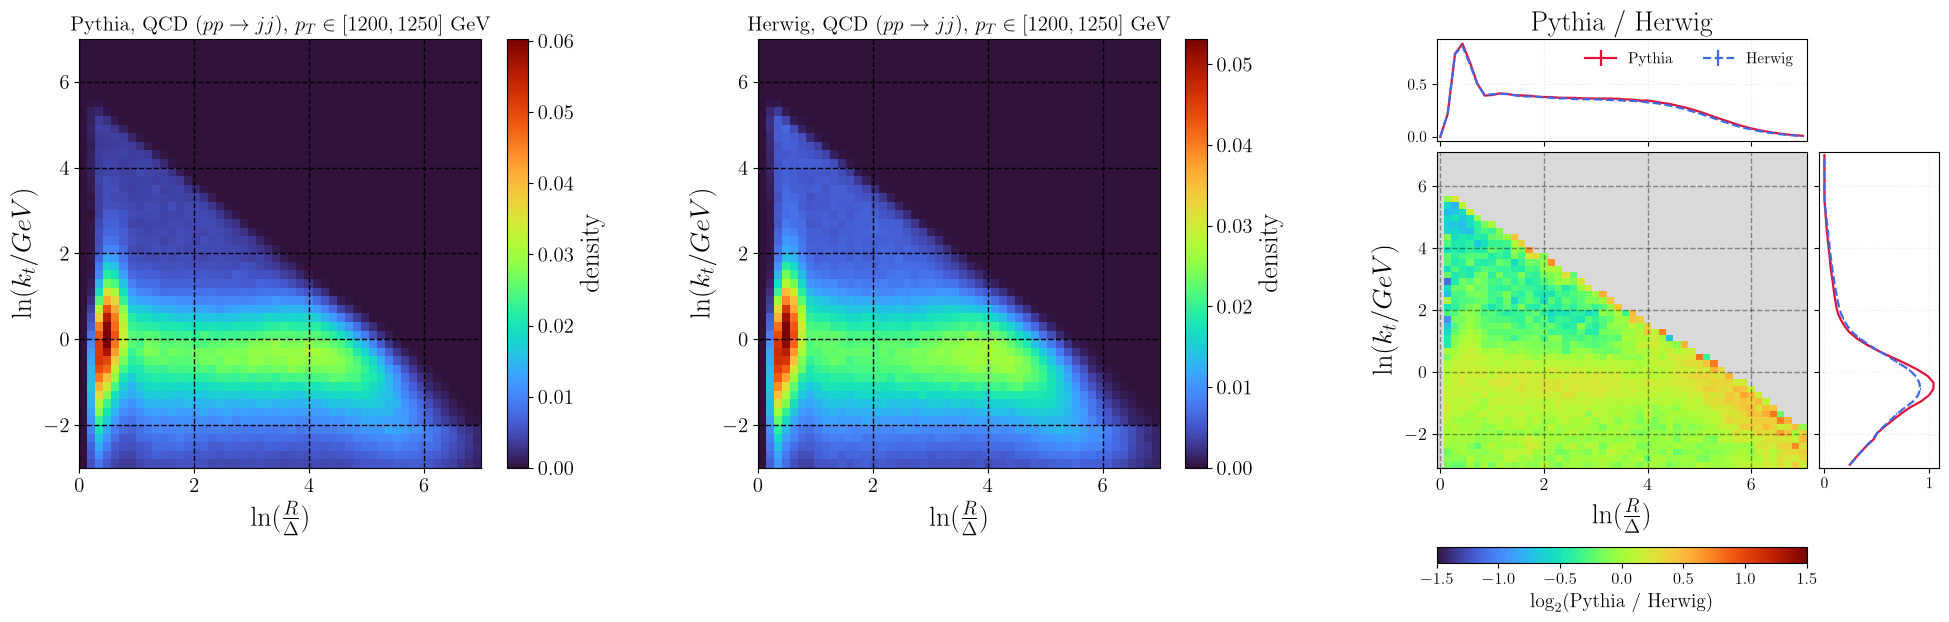

In [13]:

xval = [0, 7]
yval = [-3, 7]
 
fig = plt.figure(figsize=(20, 6.5))          # a bit wider: panel 3 holds 3 axes
## fig.subplots_adjust(hspace=1, wspace=1)   # removed: it overrides the inner
                                             # spacing of the nested gridspec
y1 = fig.add_subplot(131)
c1 = y1.imshow(np.average(im_p, axis=0).T, origin='lower', aspect='auto', extent=xval+yval, cmap='turbo')
y1.set_xlabel(r'$\ln(\frac{R}{\Delta})$', fontsize=20)
y1.set_ylabel(r'$\ln(k_t/GeV)$', fontsize=20)
plt.tick_params(axis='both', labelsize=15)
cbar1 = plt.colorbar(c1)
cbar1.ax.tick_params(labelsize=15)
cbar1.set_label(r'density',fontsize=20)
y1.grid(color='k', linestyle='--', linewidth=1.01)
y1.set_title(r"Pythia, QCD $(pp\to jj)$, $p_T \in [1200,1250]$ GeV", fontsize=15)
 
y2 = fig.add_subplot(132)
c2 = y2.imshow(np.average(im_h, axis=0).T, origin='lower', aspect='auto', extent=xval+yval, cmap='turbo')
y2.set_xlabel(r'$\ln(\frac{R}{\Delta})$', fontsize=20)
y2.set_ylabel(r'$\ln(k_t/GeV)$', fontsize=20)
plt.tick_params(axis='both', labelsize=15)
y2.set_title(r"Herwig, QCD $(pp\to jj)$, $p_T \in [1200,1250]$ GeV", fontsize=15)
cbar2 = plt.colorbar(c2)
cbar2.ax.tick_params(labelsize=15)
cbar2.set_label(r'density',fontsize=20)
y2.grid(color='k', linestyle='--', linewidth=1.01)
 
# =====================================================================
# THIRD PANEL  (replaces y3 = fig.add_subplot(133) and the ratio imshow)
# =====================================================================
# add_subplot(133) gives one axes; the joint plot needs three, so the third
# cell of a 1x3 grid is subdivided with .subgridspec().
inner = fig.add_gridspec(1, 3)[0, 2].subgridspec(
    2, 2, width_ratios=(4, 1.3), height_ratios=(1.3, 4), wspace=0.05, hspace=0.05)
ax_c = fig.add_subplot(inner[1, 0])                    # centre: 2D map
ax_t = fig.add_subplot(inner[0, 0], sharex=ax_c)       # top marginal
ax_r = fig.add_subplot(inner[1, 1], sharey=ax_c)       # right marginal
 
nx, ny = im_p.shape[1], im_p.shape[2]
x = np.linspace(xval[0], xval[1], nx)
y = np.linspace(yval[0], yval[1], ny)
X, Y = np.meshgrid(x, y)
 
mp, mh = im_p.mean(0).T, im_h.mean(0).T
sp = im_p.std(0, ddof=1).T / np.sqrt(len(im_p))
sh = im_h.std(0, ddof=1).T / np.sqrt(len(im_h))
poor = ((im_p > 0).sum(0).T < 20) | ((im_h > 0).sum(0).T < 20)
 
# centre: log2 ratio, white = the two generators agree
with np.errstate(divide='ignore', invalid='ignore'):
    Z = np.log2(mp / mh)
Z = np.ma.masked_array(Z, mask=poor | ~np.isfinite(Z))
cmap = plt.get_cmap('turbo').copy()
cmap.set_bad('0.85')                                   # low-statistics bins grey
c3 = ax_c.pcolormesh(X, Y, Z, cmap=cmap,
                     norm=TwoSlopeNorm(0, -1.5, 1.5), shading='auto')
ax_c.set_xlabel(r'$\ln(\frac{R}{\Delta})$', fontsize=20)
ax_c.set_ylabel(r'$\ln(k_t/GeV)$', fontsize=20)
ax_c.tick_params(axis='both', labelsize=13)
ax_c.grid(color='k', linestyle='--', linewidth=1.01, alpha=0.4)
 
# marginals: sum each JET's image along one axis, then average, so the
# per-jet spread survives and the error bars have something to come from
px_p, px_h = im_p.sum(2), im_h.sum(2)
py_p, py_h = im_p.sum(1), im_h.sum(1)
mx_p, ex_p = px_p.mean(0), px_p.std(0, ddof=1) / np.sqrt(len(px_p))
mx_h, ex_h = px_h.mean(0), px_h.std(0, ddof=1) / np.sqrt(len(px_h))
my_p, ey_p = py_p.mean(0), py_p.std(0, ddof=1) / np.sqrt(len(py_p))
my_h, ey_h = py_h.mean(0), py_h.std(0, ddof=1) / np.sqrt(len(py_h))
 
ax_t.errorbar(x, mx_p, yerr=ex_p, fmt='-', color='crimson', lw=1.6, label='Pythia')
ax_t.errorbar(x, mx_h, yerr=ex_h, fmt='--', color='royalblue', lw=1.6, label='Herwig')
ax_t.set_title(r'Pythia / Herwig', fontsize=20)
ax_t.legend(fontsize=11, ncol=2, frameon=False)
ax_t.tick_params(labelbottom=False, labelsize=11)
ax_t.grid(alpha=0.3, ls=':')
 
ax_r.errorbar(my_p, y, xerr=ey_p, fmt='-', color='crimson', lw=1.6)
ax_r.errorbar(my_h, y, xerr=ey_h, fmt='--', color='royalblue', lw=1.6)
ax_r.tick_params(labelleft=False, labelsize=11)
ax_r.grid(alpha=0.3, ls=':')
 
# colourbar under the centre panel; inset_axes is relative to ax_c, so it
# stays put if the layout changes
cax = ax_c.inset_axes([0, -0.30, 1, 0.05])
cb = fig.colorbar(c3, cax=cax, orientation='horizontal')
cb.set_label(r'$\log_2$(Pythia / Herwig)', fontsize=14)
cb.ax.tick_params(labelsize=12)
 
## plt.tight_layout()   # removed: it cannot handle the nested gridspec and
                        # pushes the marginals out of line with the centre
fig.subplots_adjust(left=0.05, right=0.98, top=0.90, bottom=0.24, wspace=0.35)
plt.savefig('stat_full_qcd.pdf')